# CSE 153 Audio Project

This notebook summarizes the main pipeline we used for the project:

1. Split and organize the raw audio.
2. Normalize the data and rebuild fixed-length audio.
3. Create augmentations.
4. Transcribe audio to MIDI with Spotify Basic Pitch.
5. Review results with a small human evaluation.

In [18]:
from pathlib import Path
import sys

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path("src")))

from librosa_audio_utils import configure_logging, duration_samples, find_audio_files, fix_length, load_audio, write_audio
from rebuild_audio_librosa import (
    add_background_noise,
    build_augmentations,
    build_processed_outputs,
    collect_sources,
    compute_target_length,
    pitch_shift_audio,
    time_stretch_audio,
)

## 0. Data Split and Organization

We organized the dataset into raw, split, processed, augmented, and MIDI folders so each step of the pipeline stayed separate and reproducible.

In [19]:
project_dirs = {
    "raw flat": Path("data/raw/flat"),
    "raw dropbox": Path("data/raw/dropbox"),
    "split audio": Path("data/split_audio"),
    "processed audio": Path("data/audio/processed"),
    "augmented audio": Path("data/audio/augmented"),
    "midi": Path("data/midi"),
}

rows = []
for label, folder in project_dirs.items():
    count = sum(1 for path in folder.rglob("*.*") if path.is_file()) if folder.exists() else 0
    rows.append({"folder": label, "path": str(folder), "files": count})

folder_summary = pd.DataFrame(rows)
folder_summary

,folder,path,files
0,raw flat,data\raw\flat,201
1,raw dropbox,data\raw\dropbox,150
2,split audio,data\split_audio,0
3,processed audio,data\audio\processed,213
4,augmented audio,data\audio\augmented,791
5,midi,data\midi,214


In [20]:
# Key split-audio helpers (from src/split_audio.py)
from dataclasses import dataclass
from pathlib import Path

@dataclass(frozen=True)
class Segment:
    index: int
    start_ms: int
    end_ms: int

    @property
    def duration_ms(self) -> int:
        return self.end_ms - self.start_ms


def merge_close_segments(segments, merge_gap_ms: int):
    """Merge segments separated by gaps <= merge_gap_ms."""
    merged = []
    for segment in sorted(segments, key=lambda s: s.start_ms):
        if not merged:
            merged.append(segment)
            continue
        prev = merged[-1]
        gap = segment.start_ms - prev.end_ms
        if gap <= merge_gap_ms:
            merged[-1] = Segment(index=0, start_ms=prev.start_ms, end_ms=max(prev.end_ms, segment.end_ms))
        else:
            merged.append(segment)
    return merged


def estimate_clip_duration_ms(segments):
    """Return a reasonable target clip duration (median of segments), or None."""
    if not segments:
        return None
    durations = sorted(s.duration_ms for s in segments)
    import statistics
    median_ms = int(statistics.median(durations))
    if median_ms < 2000:
        return None
    return median_ms

## 1. Data Processing

We start from the raw flat WAV files and Dropbox MP3 files, then normalize everything to mono at 32 kHz and a shared integer-second length.

In [21]:
sample_rate = 32000
flat_files, dropbox_files = collect_sources(Path("data/raw/flat"), Path("data/raw/dropbox"))
target_length = compute_target_length(flat_files, dropbox_files, sample_rate)

print(f"flat files: {len(flat_files)}")
print(f"dropbox files: {len(dropbox_files)}")
print(f"target length: {target_length} samples ({target_length / sample_rate:.0f} s)")

# Actual processing step used in the project:
# flat_audio, dropbox_audio = build_processed_outputs(
#     flat_files=flat_files,
#     dropbox_files=dropbox_files,
#     audio_root=Path("data/audio"),
#     sample_rate=sample_rate,
#     target_length=target_length,
# )

raw_summary = pd.DataFrame(
    [
        {"group": "flat", "files": len(flat_files)},
        {"group": "dropbox", "files": len(dropbox_files)},
    ]
)
raw_summary

flat files: 65
dropbox files: 148
target length: 896000 samples (28 s)


,group,files
0,flat,65
1,dropbox,148


In [22]:
# Data processing helpers (from src/rebuild_audio_librosa.py)
from pathlib import Path
import math


def collect_sources(flat_source_dir: Path, dropbox_source_dir: Path):
    flat_files = list(Path(flat_source_dir).glob("*.wav"))
    dropbox_files = list(Path(dropbox_source_dir).glob("*.mp3"))
    return sorted(flat_files), sorted(dropbox_files)


def compute_target_length(flat_files, dropbox_files, sample_rate: int) -> int:
    """Compute a shared target length (rounded up to whole seconds)."""
    import librosa
    max_length = 0
    for p in [*flat_files, *dropbox_files]:
        audio, _ = librosa.load(p, sr=sample_rate, mono=True)
        max_length = max(max_length, audio.shape[0])
    target_seconds = math.ceil(max_length / sample_rate)
    return target_seconds * sample_rate


def build_processed_outputs(flat_files, dropbox_files, audio_root: Path, sample_rate: int, target_length: int):
    """Load, normalize to mono/sr, fix length, and write processed WAVs."""
    import soundfile as sf
    import librosa
    flat_out = audio_root / "processed" / "flat"
    dropbox_out = audio_root / "processed" / "dropbox"
    flat_out.mkdir(parents=True, exist_ok=True)
    dropbox_out.mkdir(parents=True, exist_ok=True)

    for i, p in enumerate(sorted(flat_files), start=1):
        audio, _ = librosa.load(p, sr=sample_rate, mono=True)
        audio = librosa.util.fix_length(audio.astype('float32'), size=target_length)
        sf.write(flat_out / f"{i:03d}.wav", audio, sample_rate, subtype='PCM_16')

    for i, p in enumerate(sorted(dropbox_files), start=1):
        audio, _ = librosa.load(p, sr=sample_rate, mono=True)
        audio = librosa.util.fix_length(audio.astype('float32'), size=target_length)
        sf.write(dropbox_out / f"{i:03d}.wav", audio, sample_rate, subtype='PCM_16')

    return None

## 2. Augmentation

We used three augmentations to expand the dataset: background noise, pitch shift, and speed up.

In [23]:
audio_path = Path("data/raw/flat/001.wav")
audio = load_audio(audio_path, sample_rate)

# Actual augmentation functions used in the project.
# They match src/rebuild_audio_librosa.py.

def add_background_noise(audio: np.ndarray, noise_db: float, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    noise = rng.standard_normal(len(audio)).astype(np.float32)
    signal_rms = float(np.sqrt(np.mean(audio**2))) if len(audio) else 0.0
    signal_rms = max(signal_rms, 1e-4)
    noise_rms = signal_rms * (10.0 ** (noise_db / 20.0))
    noise = noise / max(float(np.sqrt(np.mean(noise**2))), 1e-8) * noise_rms
    mixed = audio + noise
    return np.clip(mixed, -1.0, 1.0).astype(np.float32)


def pitch_shift_audio(audio: np.ndarray, sample_rate: int, semitones: float) -> np.ndarray:
    shifted = librosa.effects.pitch_shift(audio, sr=sample_rate, n_steps=semitones)
    return shifted.astype(np.float32, copy=False)


def time_stretch_audio(audio: np.ndarray, rate: float) -> np.ndarray:
    stretched = librosa.effects.time_stretch(audio, rate=rate)
    return stretched.astype(np.float32, copy=False)


noisy = fix_length(add_background_noise(audio, noise_db=-24.0, seed=1), target_length)
shifted = fix_length(pitch_shift_audio(audio, sample_rate, semitones=2.0), target_length)
sped_up = fix_length(time_stretch_audio(audio, rate=1.25), target_length)

print(f"original samples: {len(audio)}")
print(f"noise samples: {len(noisy)}")
print(f"pitch shift samples: {len(shifted)}")
print(f"speed up samples: {len(sped_up)}")

# Actual rebuild call used in the project:
# build_augmentations(
#     audio_sets={"flat": flat_audio, "dropbox": dropbox_audio},
#     audio_root=Path("data/audio"),
#     sample_rate=sample_rate,
#     target_length=target_length,
#     pitch_semitones=2.0,
#     speed_up_rate=1.25,
#     noise_db=-24.0,
# )

original samples: 239360
noise samples: 896000
pitch shift samples: 896000
speed up samples: 896000


## 3. Transcribe to MIDI

After splitting the audio, we ran Spotify Basic Pitch to convert the WAV files into MIDI and note-event CSVs.

In [24]:
transcription_command = [
    "src/transcribe_basic_pitch.py",
    "--input-dir",
    "data/split_audio",
    "--output-dir",
    "data/midi",
    "--overwrite",
]

transcription_command

# The script uses Spotify Basic Pitch to:
# 1. load the pretrained ICASSP_2022 model,
# 2. predict notes from audio,
# 3. write .mid files,
# 4. save note-event CSVs and summary tables.

['src/transcribe_basic_pitch.py',
 '--input-dir',
 'data/split_audio',
 '--output-dir',
 'data/midi',
 '--overwrite']

In [25]:
# Transcription helpers (from src/transcribe_basic_pitch.py)
import csv
from pathlib import Path


def load_basic_pitch():
    try:
        from basic_pitch import ICASSP_2022_MODEL_PATH
        from basic_pitch.inference import Model, predict
    except Exception as exc:
        raise RuntimeError("basic-pitch not installed in this environment") from exc
    return ICASSP_2022_MODEL_PATH, Model, predict


def write_note_events(note_events, output_path: Path, include_pitch_bends: bool):
    with output_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        fieldnames = ["start_s", "end_s", "duration_s", "pitch_midi", "velocity"]
        if include_pitch_bends:
            fieldnames.append("pitch_bend")
        writer.writerow(fieldnames)
        for event in note_events:
            start_s, end_s, pitch_midi, amplitude, pitch_bends = event
            velocity = int(round(127 * float(amplitude)))
            row = [f"{float(start_s):.6f}", f"{float(end_s):.6f}", f"{float(end_s)-float(start_s):.6f}", int(pitch_midi), velocity]
            if include_pitch_bends:
                row.append(" ".join(str(int(v)) for v in (pitch_bends or [])))
            writer.writerow(row)


def summarize_note_events(note_events):
    if not note_events:
        return {"note_count": 0, "duration_s": 0.0, "min_pitch": None, "max_pitch": None, "mean_pitch": None, "mean_velocity": None}
    pitches = [int(e[2]) for e in note_events]
    velocities = [127 * float(e[3]) for e in note_events]
    duration_s = max(float(e[1]) for e in note_events)
    return {"note_count": len(note_events), "duration_s": duration_s, "min_pitch": min(pitches), "max_pitch": max(pitches), "mean_pitch": sum(pitches)/len(pitches), "mean_velocity": sum(velocities)/len(velocities)}


def transcribe_file(audio_path: Path, output_dir: Path, note_events_dir: Path | None, predict_fn, model, args):
    midi_path = output_dir / f"{audio_path.stem}.mid"
    note_events_path = (note_events_dir / f"{audio_path.stem}_notes.csv") if note_events_dir else None

    try:
        _, midi_data, note_events = predict_fn(
            audio_path,
            model,
            onset_threshold=args.get('onset_threshold', 0.5),
            frame_threshold=args.get('frame_threshold', 0.3),
            minimum_note_length=args.get('minimum_note_length_ms', 127.7),
            minimum_frequency=args.get('minimum_frequency'),
            maximum_frequency=args.get('maximum_frequency'),
            multiple_pitch_bends=args.get('multiple_pitch_bends', False),
            melodia_trick=not args.get('disable_melodia_trick', False),
            midi_tempo=args.get('midi_tempo', 120.0),
        )
        midi_data.write(str(midi_path))
        if note_events_path:
            write_note_events(note_events, note_events_path, include_pitch_bends=args.get('include_pitch_bends', False))
        stats = summarize_note_events(note_events)
        return {'status': 'ok', **stats}
    except Exception as e:
        return {'status': 'error', 'error': str(e), 'note_count': 0, 'duration_s': 0.0}


## 4. Quick Visual Check

A small spectrogram comparison is enough to confirm the processing and augmentation steps are behaving as expected.

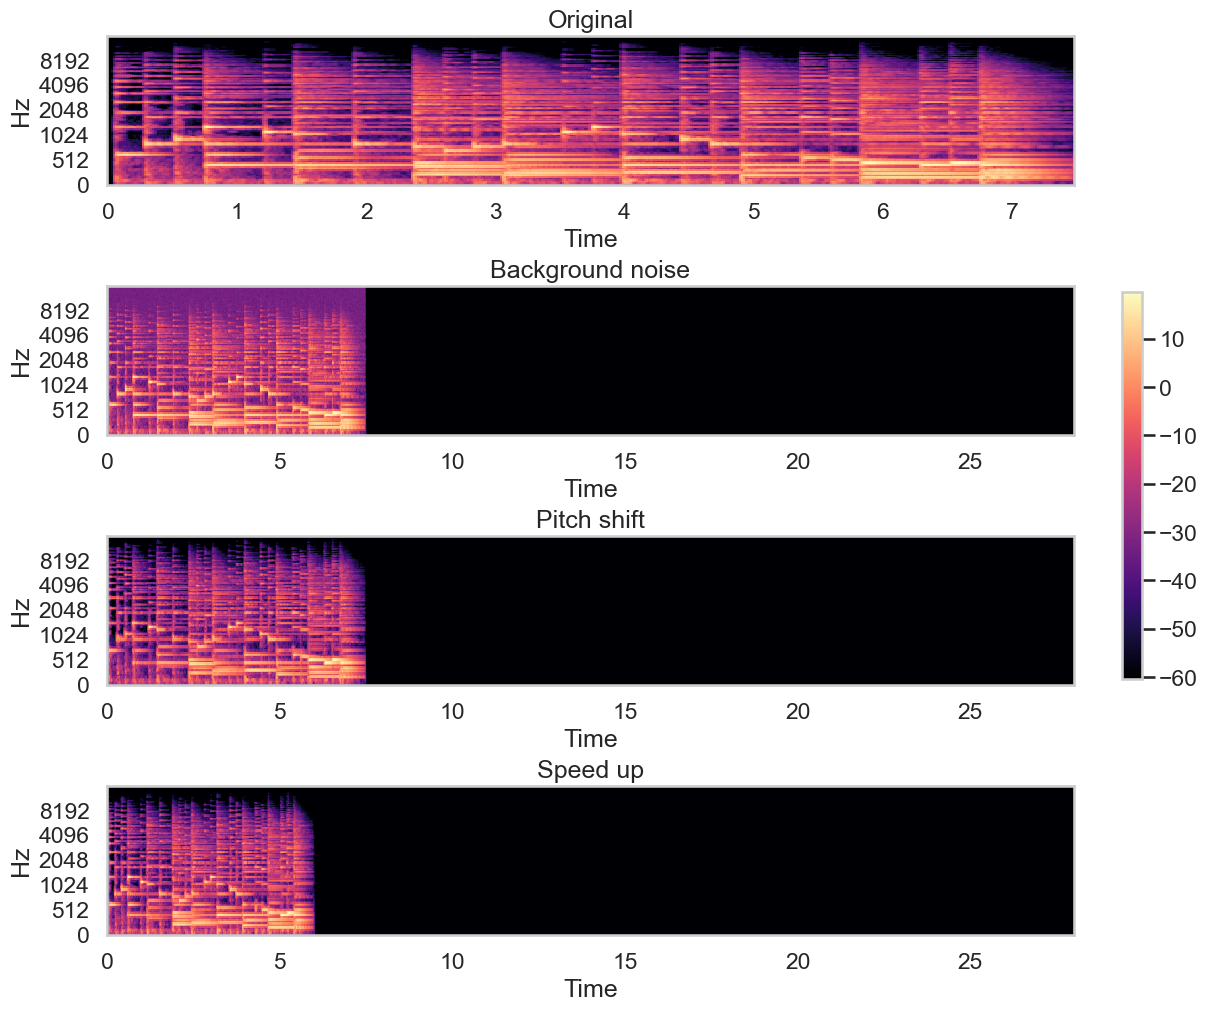

Generated pitch histograms for 2 MIDI groups in data\pitch_histograms
source_group  total_notes  files
     dropbox        16003    148
        flat         5120     65

Displaying per-group histogram images:


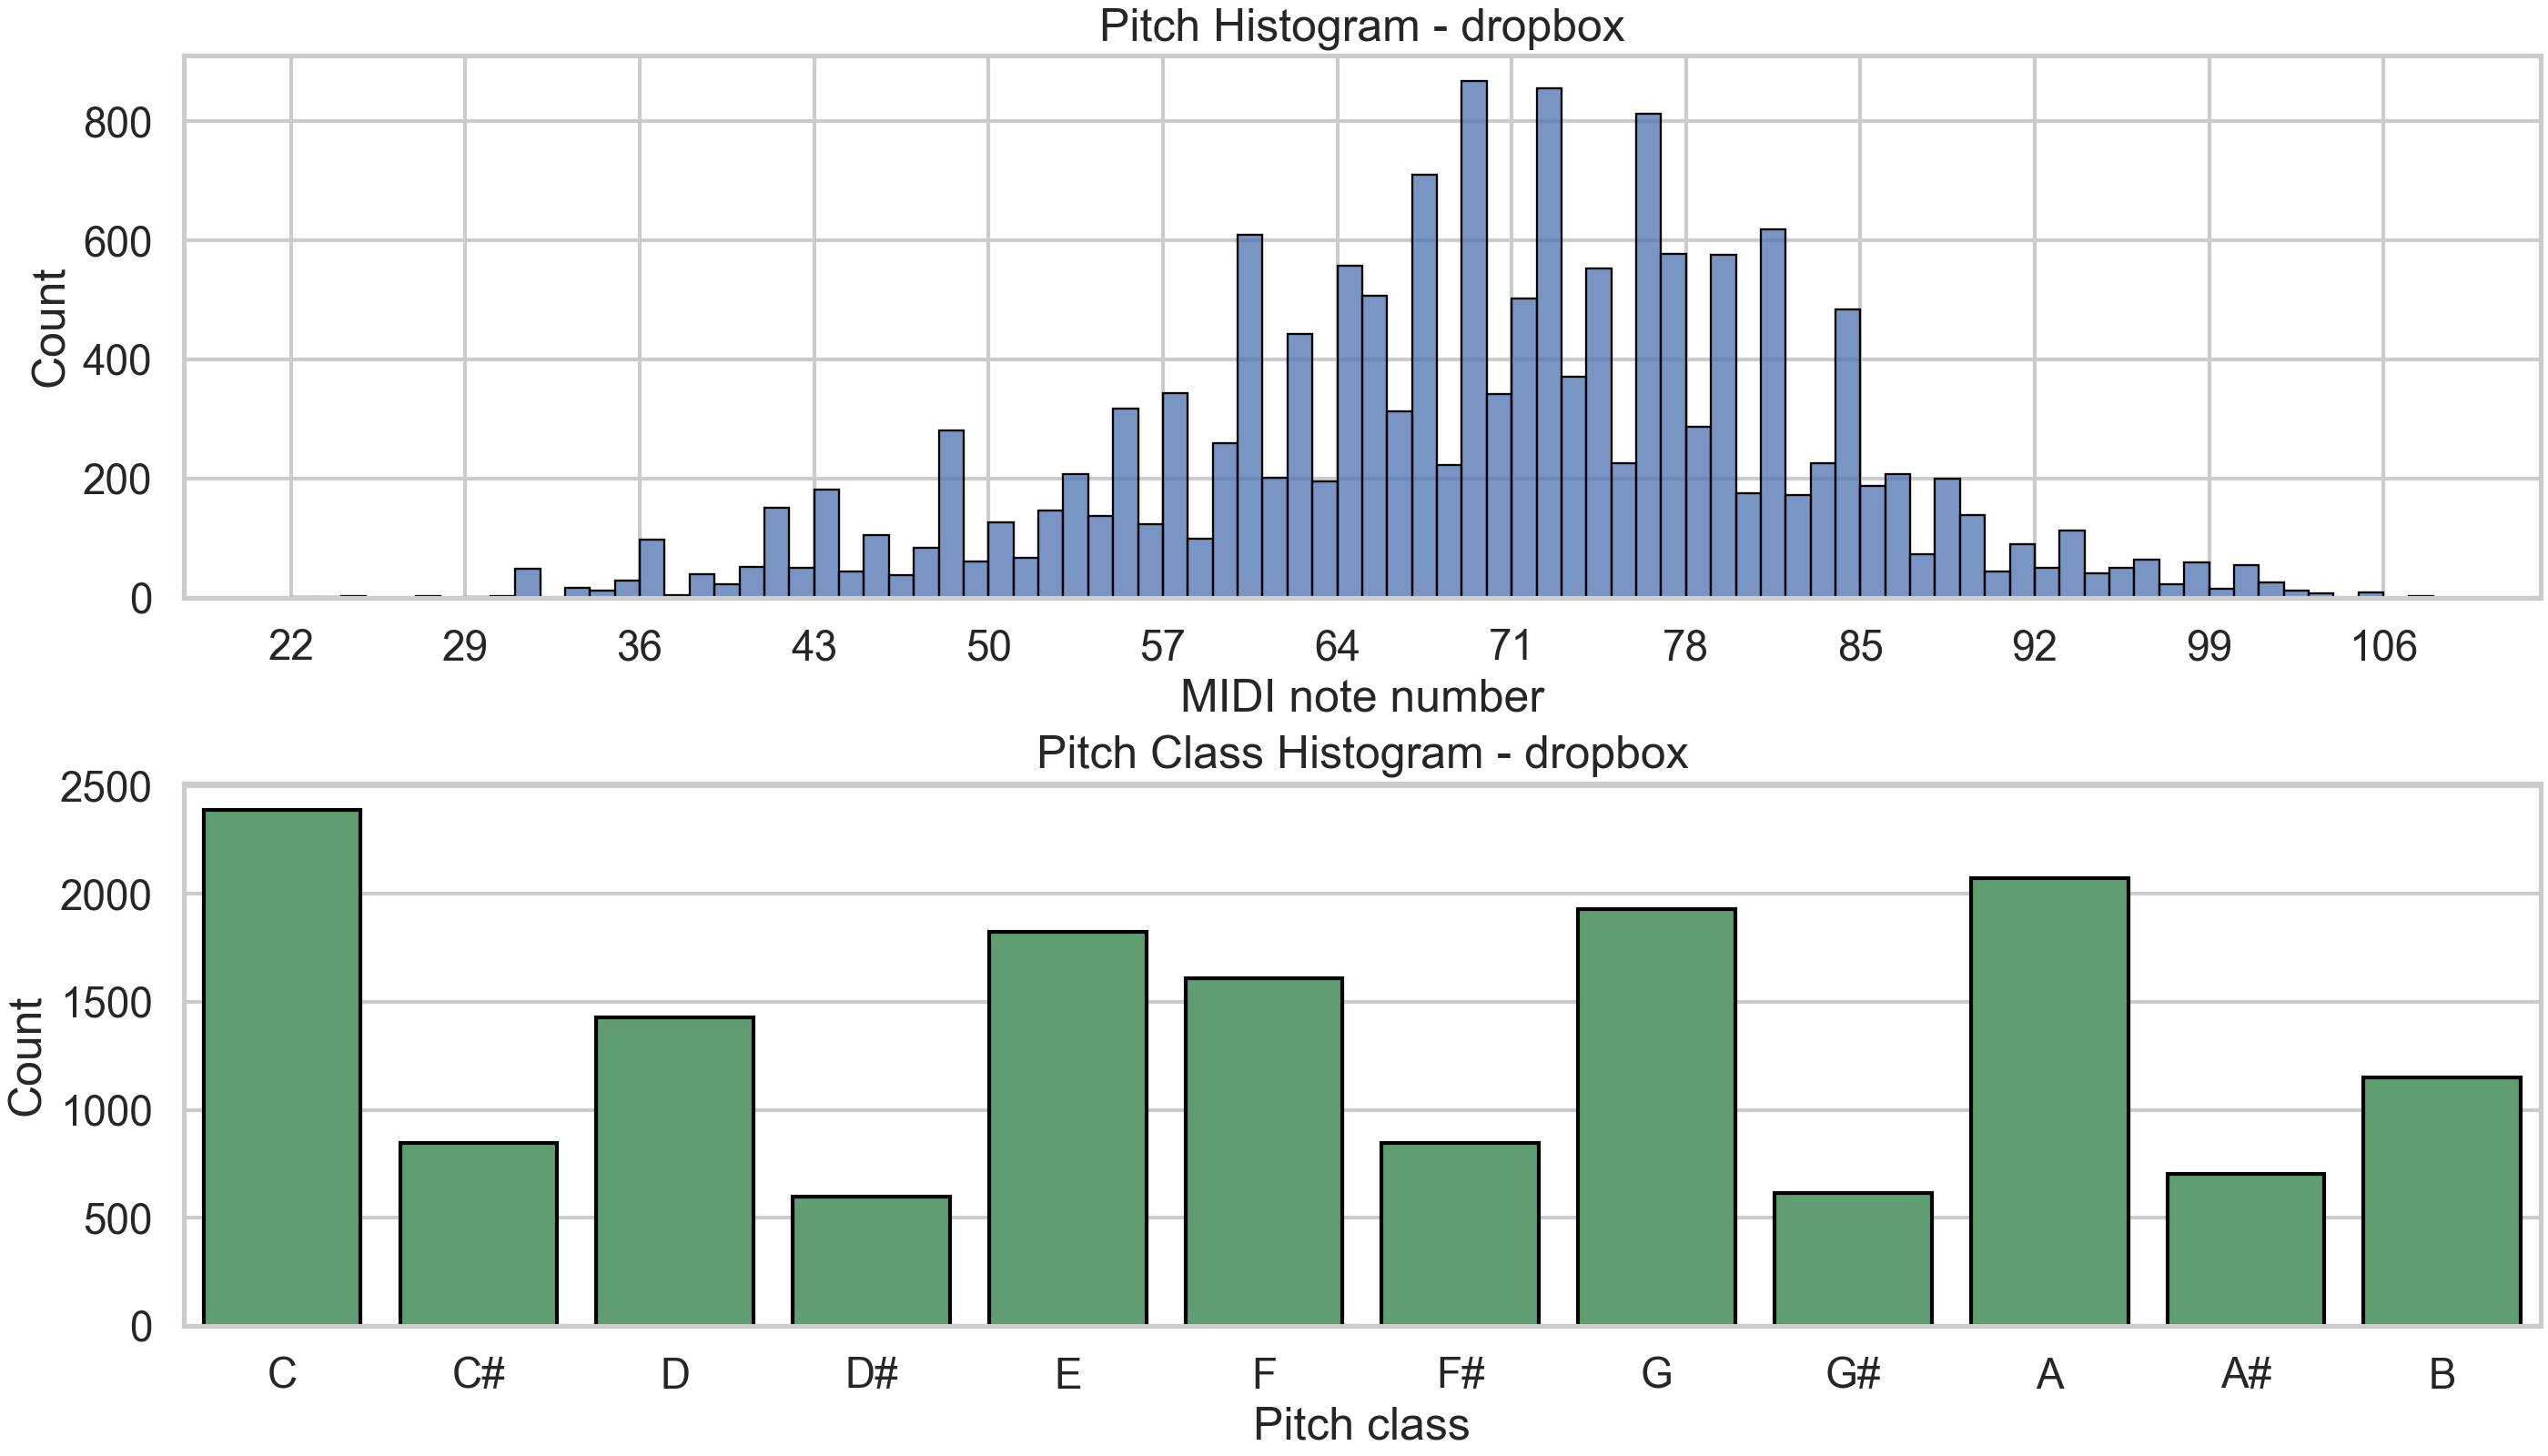

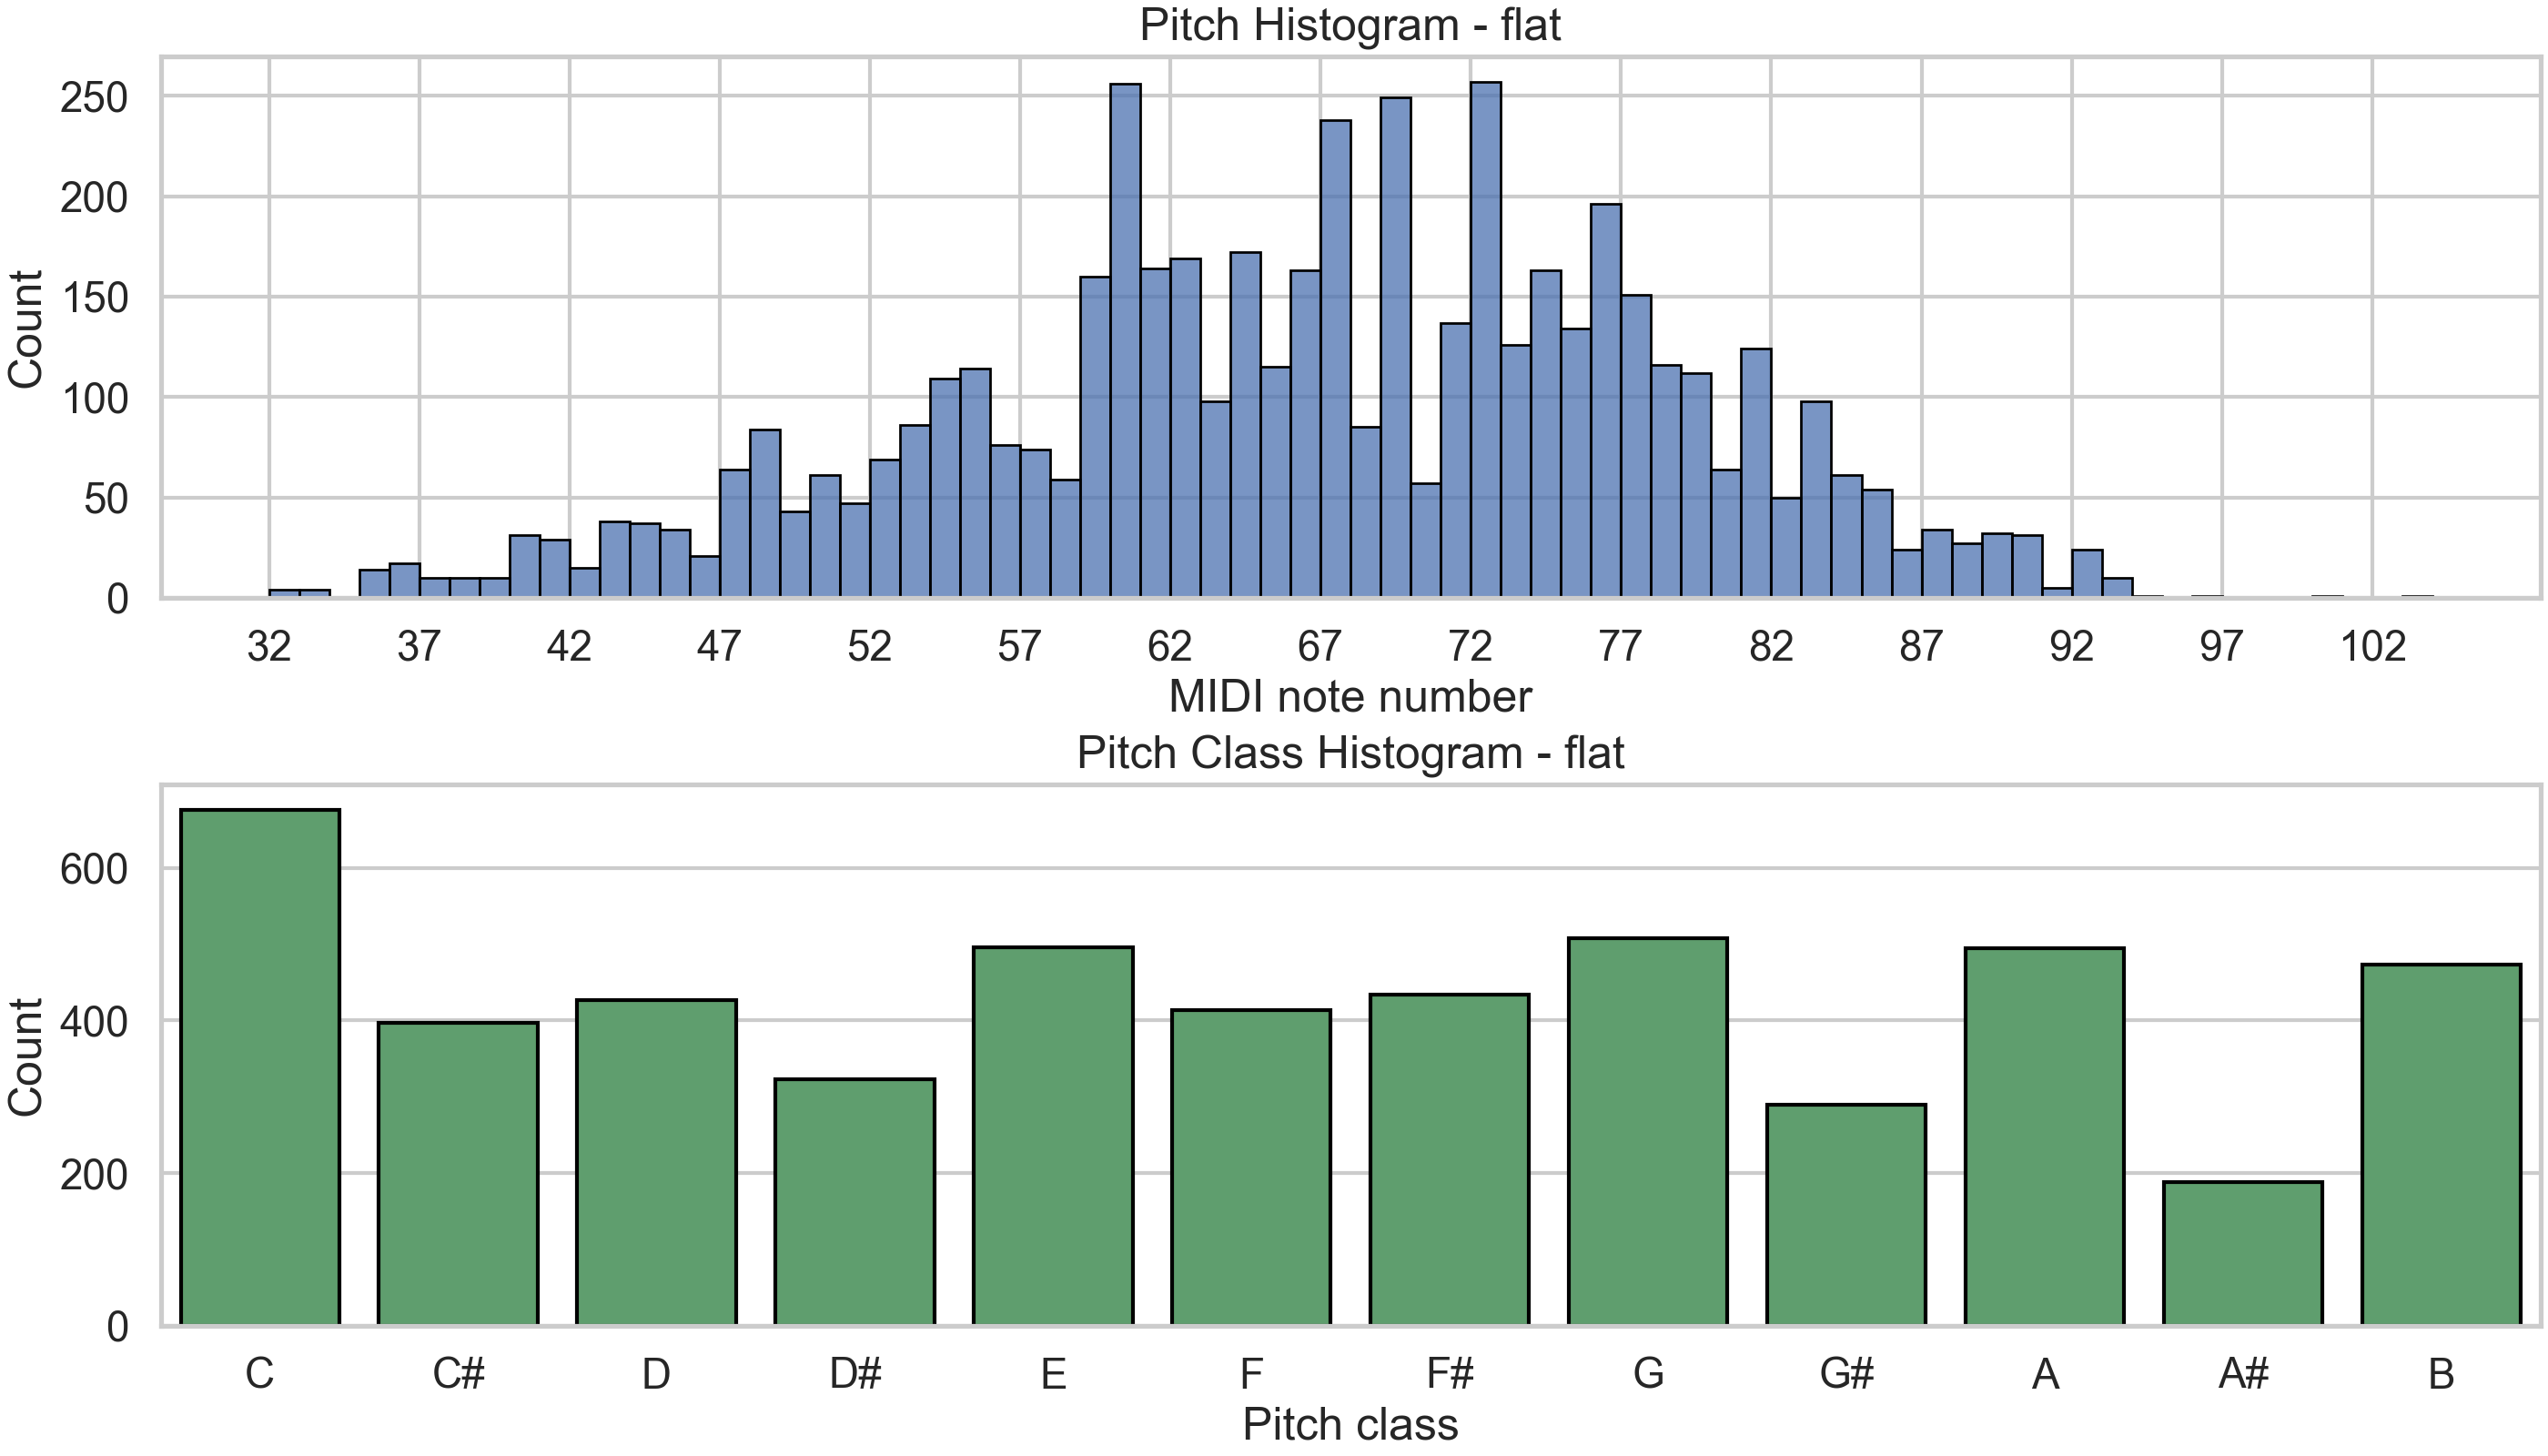

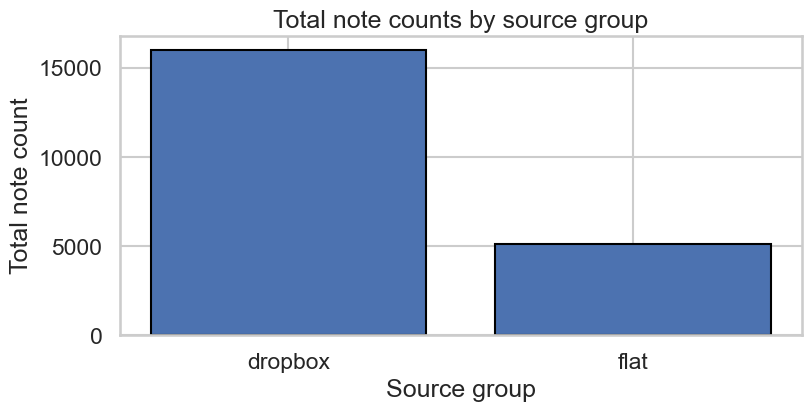

In [ ]:
# Quick visual check: aligned spectrograms for original + augmentations
import matplotlib.pyplot as plt
import librosa
import librosa.display
import pandas as pd
import sys
from pathlib import Path
from IPython.display import display, Image

examples = [
    (audio, 'Original'),
    (noisy, 'Background noise'),
    (shifted, 'Pitch shift'),
    (sped_up, 'Speed up'),
]

fig, axes = plt.subplots(4, 1, figsize=(12, 10), constrained_layout=True)
for ax, (sig, title) in zip(axes, examples):
    if sig is None or len(sig) == 0:
        ax.text(0.5, 0.5, 'No signal', ha='center', va='center')
        continue
    mel = librosa.feature.melspectrogram(y=sig, sr=sample_rate, n_fft=2048, hop_length=512, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=1.0)
    img = librosa.display.specshow(mel_db, sr=sample_rate, hop_length=512, x_axis='time', y_axis='mel', ax=ax, cmap='magma')
    ax.set_title(title)

cbar = fig.colorbar(img, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.02)

# Save a copy for the slides
out_dir = Path('data/spectrograms/slide_assets_trimmed')
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / 'visual_check_examples.png', dpi=200)
plt.show()

# --- Pitch histograms ---
src_dir = Path('src').resolve()
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from pitch_histogram import collect_groups, plot_histograms, summarize_group, write_summary_csv

midi_dir = Path('data/midi')
hist_dir = Path('data/pitch_histograms')
summary_csv = hist_dir / 'pitch_histogram_summary.csv'

groups = collect_groups(midi_dir, '*.mid', group_by_subdir=True)
if groups:
    all_records = []
    for group_name, midi_files in groups.items():
        pitches, records = summarize_group(group_name, midi_files)
        if pitches:
            plot_histograms(group_name, pitches, hist_dir)
        all_records.extend(records)
    write_summary_csv(all_records, summary_csv)
    print(f'Generated pitch histograms for {len(groups)} MIDI groups in {hist_dir}')
else:
    print(f'No MIDI files found under {midi_dir}')


if summary_csv.exists():
    df = pd.read_csv(summary_csv)
    if not df.empty:
        agg = df.groupby('source_group', as_index=False).agg(total_notes=('note_count','sum'), files=('midi_file','size'))
        fig2, ax2 = plt.subplots(figsize=(8,4), constrained_layout=True)
        agg.sort_values('total_notes', ascending=False, inplace=True)
        ax2.bar(agg['source_group'], agg['total_notes'], color='#4C72B0', edgecolor='black')
        ax2.set_xlabel('Source group')
        ax2.set_ylabel('Total note count')
        ax2.set_title('Total note counts by source group')
        out_path = hist_dir / 'notebook_total_notes_by_group.png'
        out_path.parent.mkdir(parents=True, exist_ok=True)
        fig2.savefig(out_path, dpi=200)
        plt.show()
        print(agg.to_string(index=False))
    else:
        print('Summary CSV is empty.')
else:
    print(f'Missing summary CSV: {summary_csv}')

# Display any saved histogram PNGs
pngs = sorted(hist_dir.glob('*_pitch_histogram.png')) if hist_dir.exists() else []
if pngs:
    print('\nDisplaying per-group histogram images:')
    for p in pngs:
        display(Image(str(p)))
else:
    print('No per-group histogram PNGs found in', hist_dir)


## 5. Human Evaluation

We also asked a listener to rate generated melodies from 1 to 5, then compared the average scores for pretrained, unconditional, and conditional samples.

C:\Users\phill\AppData\Local\Temp\ipykernel_12612\3943997304.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='model', y='mean_quality', ax=ax, palette='pastel', edgecolor='black')
C:\Users\phill\AppData\Local\Temp\ipykernel_12612\3943997304.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.capitalize() for label in summary['model']])


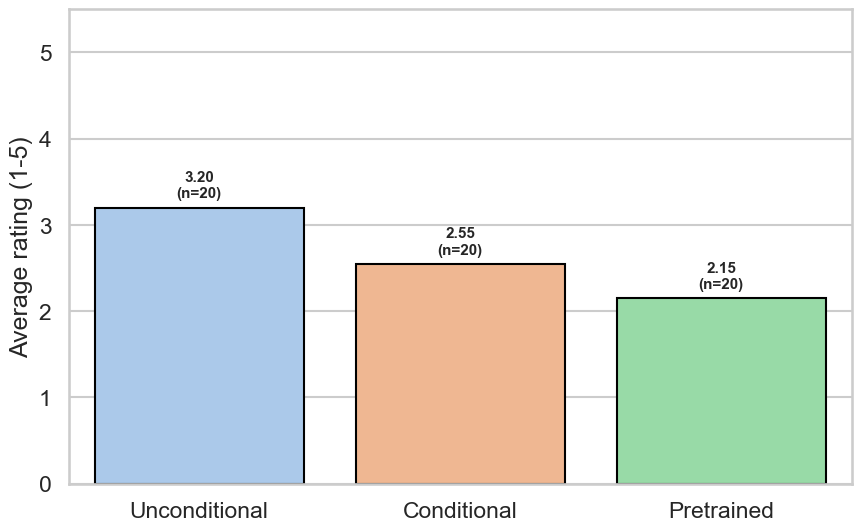

        model  mean_quality  ratings
unconditional          3.20       20
  conditional          2.55       20
   pretrained          2.15       20


In [33]:
# Human evaluation: compute averages and plot with seaborn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

forms = pd.read_csv(Path('evaluation/user_test/forms2.csv'))
references = pd.read_csv(Path('evaluation/user_test_references.csv'))
merged = forms.merge(references, on='sample', validate='one_to_one')

rows = []
for _, row in merged.iterrows():
    rows.append({'model': row['melody1'], 'quality': row['melody1_quality']})
    rows.append({'model': row['melody2'], 'quality': row['melody2_quality']})
    rows.append({'model': row['melody3'], 'quality': row['melody3_quality']})

ratings = pd.DataFrame(rows)
summary = (
    ratings.groupby('model', as_index=False)
    .agg(mean_quality=('quality', 'mean'), ratings=('quality', 'size'))
    .sort_values('mean_quality', ascending=False)
)

# Save CSV
summary.to_csv(Path('evaluation/user_test/average_quality_by_model_forms2.csv'), index=False)

# Plot
sns.set_theme(style='whitegrid', context='talk')
fig, ax = plt.subplots(figsize=(8.5, 5.2), constrained_layout=True)
sns.barplot(data=summary, x='model', y='mean_quality', ax=ax, palette='pastel', edgecolor='black')
ax.set_ylim(0, 5.5)
ax.set_xlabel('')
ax.set_ylabel('Average rating (1-5)')
ax.set_xticklabels([label.capitalize() for label in summary['model']])
for i, (_, row) in enumerate(summary.iterrows()):
    ax.text(i, row['mean_quality'] + 0.08, f"{row['mean_quality']:.2f}\n(n={int(row['ratings'])})", ha='center', va='bottom', fontsize=11, weight='bold')

out_png = Path('evaluation/user_test/average_quality_by_model_forms2.png')
out_png.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_png, dpi=200)
plt.show()

print(summary.to_string(index=False))